<a href="https://colab.research.google.com/github/InOsuGay/garbage_classification/blob/dev/garbage_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ระบบจำแนกขยะจากภาพ


## 1. ติดตั้งไลบรารี

In [ ]:
%pip install -q "scikit-learn>=1.5,<1.10" "scikit-image>=0.24,<0.27" "pillow>=10,<13" "numpy>=1.26,<3" "matplotlib>=3.9,<4" "pandas>=2.2,<4" "joblib>=1.4,<2" "kagglehub>=0.3,<1" "gradio>=5,<7"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 2.8 MB/s eta 0:00:00


## 2. ตั้งค่าโครงสร้างและฟังก์ชันเตรียมภาพ

In [ ]:
from pathlib import Path
ROOT = Path("/content/garbage_sorter")
ROOT.mkdir(parents=True, exist_ok=True)
ARTIFACTS = ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
(ROOT / "features.py").write_text('"""Shared deterministic image preprocessing for training and prediction."""\nimport numpy as np\nfrom PIL import Image, ImageOps\nfrom skimage.color import rgb2gray, rgb2hsv\nfrom skimage.feature import hog\n\nCLASSES = [\'cardboard\', \'glass\', \'metal\', \'paper\', \'plastic\', \'trash\']\nTHAI = dict(zip(CLASSES, [\'กระดาษแข็ง\', \'แก้ว\', \'โลหะ\', \'กระดาษ\', \'พลาสติก\', \'ขยะทั่วไป\']))\n\ndef prepare_image(image):\n    image = ImageOps.exif_transpose(image).convert(\'RGB\')\n    return ImageOps.pad(image, (128, 128), method=Image.Resampling.BILINEAR, color=\'white\')\n\ndef extract_features(image):\n    rgb = np.asarray(prepare_image(image), dtype=np.float32) / 255.0\n    shape = hog(rgb2gray(rgb), orientations=9, pixels_per_cell=(16, 16),\n                cells_per_block=(2, 2), block_norm=\'L2-Hys\')\n    hsv = rgb2hsv(rgb)\n    colors = []\n    # Spatial color histograms retain coarse object position as well as color.\n    for row in range(2):\n        for col in range(2):\n            patch = hsv[row*64:(row+1)*64, col*64:(col+1)*64]\n            for channel in range(3):\n                hist, _ = np.histogram(patch[..., channel], bins=16, range=(0, 1))\n                colors.extend(hist / hist.sum())\n    moments = np.concatenate([rgb.mean(axis=(0,1)), rgb.std(axis=(0,1))])\n    return np.concatenate([shape, colors, moments]).astype(np.float32)\n', encoding="utf-8")
from features import CLASSES, THAI, extract_features
print("พร้อมใช้งาน:", ", ".join(THAI.values()))


พร้อมใช้งาน: กระดาษแข็ง, แก้ว, โลหะ, กระดาษ, พลาสติก, ขยะทั่วไป


## 3. ดาวน์โหลดข้อมูลจาก Kaggle

In [ ]:
DATA_MODE = "kaggle"
if DATA_MODE == "kaggle":
    import kagglehub
    DATA_ROOT = Path(kagglehub.dataset_download("asdasdasasdas/garbage-classification"))
elif DATA_MODE == "upload_zip":
    from google.colab import files
    import io, zipfile
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise ValueError("กรุณาเลือก ZIP ชุดข้อมูลเพียงไฟล์เดียว")
    DATA_ROOT = ROOT / "data"
    DATA_ROOT.mkdir(exist_ok=True)
    payload = next(iter(uploaded.values()))
    with zipfile.ZipFile(io.BytesIO(payload)) as archive:
        for member in archive.infolist():
            target = (DATA_ROOT / member.filename).resolve()
            if not target.is_relative_to(DATA_ROOT.resolve()):
                raise ValueError("ZIP มีเส้นทางไฟล์ที่ไม่ถูกต้อง")
        archive.extractall(DATA_ROOT)
else:
    raise ValueError("DATA_MODE ต้องเป็น kaggle หรือ upload_zip")
print("โฟลเดอร์ข้อมูล:", DATA_ROOT)


100%|██████████| 82.0M/82.0M [00:01<00:00, 80.2MB/s]

Extracting files...


โฟลเดอร์ข้อมูล: /root/.cache/kagglehub/datasets/asdasdasasdas/garbage-classification/versions/2


## 4. ตรวจข้อมูลและดึง Feature

In [ ]:
import argparse, csv, hashlib, json, time
from collections import Counter
from pathlib import Path
import joblib
import numpy as np
from PIL import Image, UnidentifiedImageError
from sklearn.ensemble import RandomForestClassifier ##
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from features import CLASSES, extract_features, prepare_image

def metrics(y, prediction):
    p, r, f, _ = precision_recall_fscore_support(y, prediction, average='macro', zero_division=0)
    return dict(accuracy=float(accuracy_score(y, prediction)), precision_macro=float(p), recall_macro=float(r), f1_macro=float(f))

all_image_paths = [path for path in DATA_ROOT.rglob('*') if path.is_file() and path.suffix.lower() in {'.jpg','.jpeg','.png','.bmp','.webp'}]
total_raw_images = len(all_image_paths)

records, seen, skipped, conflicts = [], {}, [], set()
for path in sorted(all_image_paths):
    label = path.parent.name.lower()
    if label not in CLASSES:
        continue
    try:
        with Image.open(path) as image:
            # Decode before hashing: identical pixels across file encodings are duplicates.
            rgb = image.convert('RGB')
            digest = hashlib.sha256(str(rgb.size).encode() + rgb.tobytes()).hexdigest()
            feature = extract_features(image)
        if digest in seen:
            if seen[digest] != label:
                conflicts.add(digest)
            skipped.append(dict(path=str(path), reason='conflicting_duplicate' if seen[digest] != label else 'duplicate'))
            continue
        seen[digest] = label
        records.append((path, label, feature, digest))
    except (UnidentifiedImageError, OSError, Image.DecompressionBombError) as exc:
        skipped.append(dict(path=str(path), reason=str(exc)))

for path,label,feature,digest in records:
    if digest in conflicts:
        skipped.append(dict(path=str(path), reason='conflicting_duplicate'))
records = [r for r in records if r[3] not in conflicts]
counts = Counter(r[1] for r in records)
if any(counts[c] < 10 for c in CLASSES):
    raise ValueError(f'Need at least 10 valid unique images per class; found {dict(counts)}. Extract Kaggle dataset under data/.')
x = np.stack([r[2] for r in records]); y = np.array([r[1] for r in records])

import pandas as pd
print(f"=== รายงานภาพรวมชุดข้อมูล ===")
print(f"จำนวนรูปภาพทั้งหมดในดาตาเซ็ตต้นฉบับ: {total_raw_images} ภาพ")
print(f"จำนวนที่ถูกตัดออก (ซ้ำ/เสียหาย/ไม่ตรงคลาส): {len(skipped)} ภาพ")
print(f"จำนวนที่เหลือใช้งานจริง (Unique Images): {len(records)} ภาพ")
print(f"รูปพรรณสัณฐานฟีเจอร์ที่สกัดเสร็จสิ้น (Feature matrix shape): {x.shape}")
print("\nจำนวนภาพที่เหลือแยกตามประเภทขยะ:")
display(pd.DataFrame({"ประเภท": list(counts), "จำนวนภาพที่พร้อมใช้": list(counts.values())}))

=== รายงานภาพรวมชุดข้อมูล ===
จำนวนรูปภาพทั้งหมดในดาตาเซ็ตต้นฉบับ: 5054 ภาพ
จำนวนที่ถูกตัดออก (ซ้ำ/เสียหาย/ไม่ตรงคลาส): 2533 ภาพ
จำนวนที่เหลือใช้งานจริง (Unique Images): 2521 ภาพ
รูปพรรณสัณฐานฟีเจอร์ที่สกัดเสร็จสิ้น (Feature matrix shape): (2521, 1962)

จำนวนภาพที่เหลือแยกตามประเภทขยะ:


,ประเภท,จำนวนภาพที่พร้อมใช้
0,cardboard,403
1,glass,498
2,metal,409
3,paper,594
4,plastic,480
5,trash,137


## 5. แบ่ง Train / Validation / Test

In [ ]:
indices = np.arange(len(y))
trainval, test = train_test_split(indices, test_size=.2, random_state=42, stratify=y)
train, valid = train_test_split(trainval, test_size=.25, random_state=42, stratify=y[trainval])
split = {int(i):name for name, group in [('train',train),('validation',valid),('test',test)] for i in group}
with (ARTIFACTS/'split_manifest.csv').open('w', newline='', encoding='utf-8') as f:
    writer=csv.writer(f); writer.writerow(['path','class','split','pixel_sha256'])
    for i, (path,label,_,digest) in enumerate(records):
        writer.writerow([str(path.relative_to(DATA_ROOT)),label,split[i],digest])

print("Train:", len(train), "Validation:", len(valid), "Test:", len(test))
assert not (set(train) & set(valid) or set(train) & set(test) or set(valid) & set(test))


Train: 1512 Validation: 504 Test: 505


## 6. ฝึกและเปรียบเทียบ 2 โมเดล


In [ ]:
models = {
    'SVM': make_pipeline(StandardScaler(), SVC(C=10, kernel='rbf', class_weight='balanced', probability=True, random_state=42)),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', min_samples_leaf=2, random_state=42, n_jobs=-1)
}
summary = dict(class_counts=dict(counts), skipped=skipped, feature_count=int(x.shape[1]),
               split_counts={k:len(v) for k,v in [('train',train),('validation',valid),('test',test)]}, seed=42, models={})
for name, model in models.items():
    start=time.time(); model.fit(x[train], y[train])
    summary['models'][name] = dict(validation=metrics(y[valid], model.predict(x[valid])), fit_seconds=time.time()-start)
    print(name, summary['models'][name], flush=True)
winner = max(models, key=lambda name: summary['models'][name]['validation']['f1_macro'])

display(pd.DataFrame({name: info["validation"] for name, info in summary["models"].items()}).T)
print("เลือกโมเดล:", winner)


SVM {'validation': {'accuracy': 0.7559523809523809, 'precision_macro': 0.7695490609742462, 'recall_macro': 0.7103493691076386, 'f1_macro': 0.7265446673632608}, 'fit_seconds': 19.003129482269287}
Random Forest {'validation': {'accuracy': 0.751984126984127, 'precision_macro': 0.7690614203422553, 'recall_macro': 0.7137442400997518, 'f1_macro': 0.7312984592858807}, 'fit_seconds': 14.999464988708496}


,accuracy,precision_macro,recall_macro,f1_macro
SVM,0.755952,0.769549,0.710349,0.726545
Random Forest,0.751984,0.769061,0.713744,0.731298


เลือกโมเดล: Random Forest


## 7. ประเมินด้วย Test และบันทึกโมเดล


Selected: Random Forest Test: {'accuracy': 0.7782178217821782, 'precision_macro': 0.7888803576795623, 'recall_macro': 0.7425781420668237, 'f1_macro': 0.7588924806872827}


,accuracy,precision_macro,recall_macro,f1_macro
SVM,0.782178,0.800419,0.758334,0.773885
Random Forest,0.778218,0.788880,0.742578,0.758892


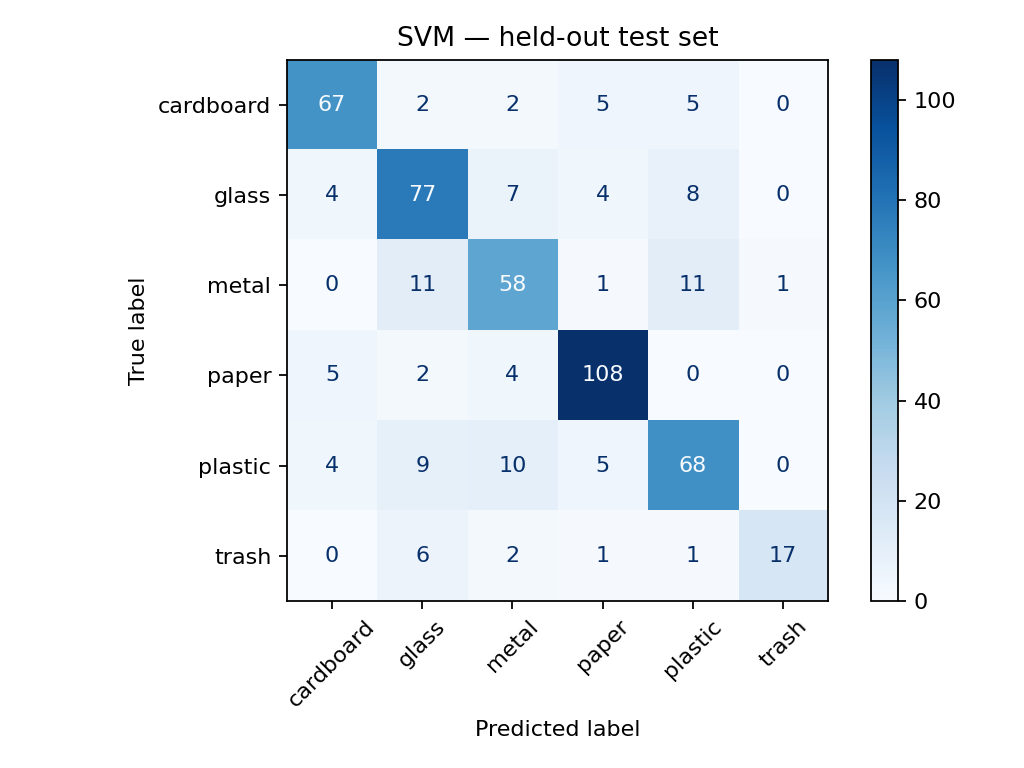

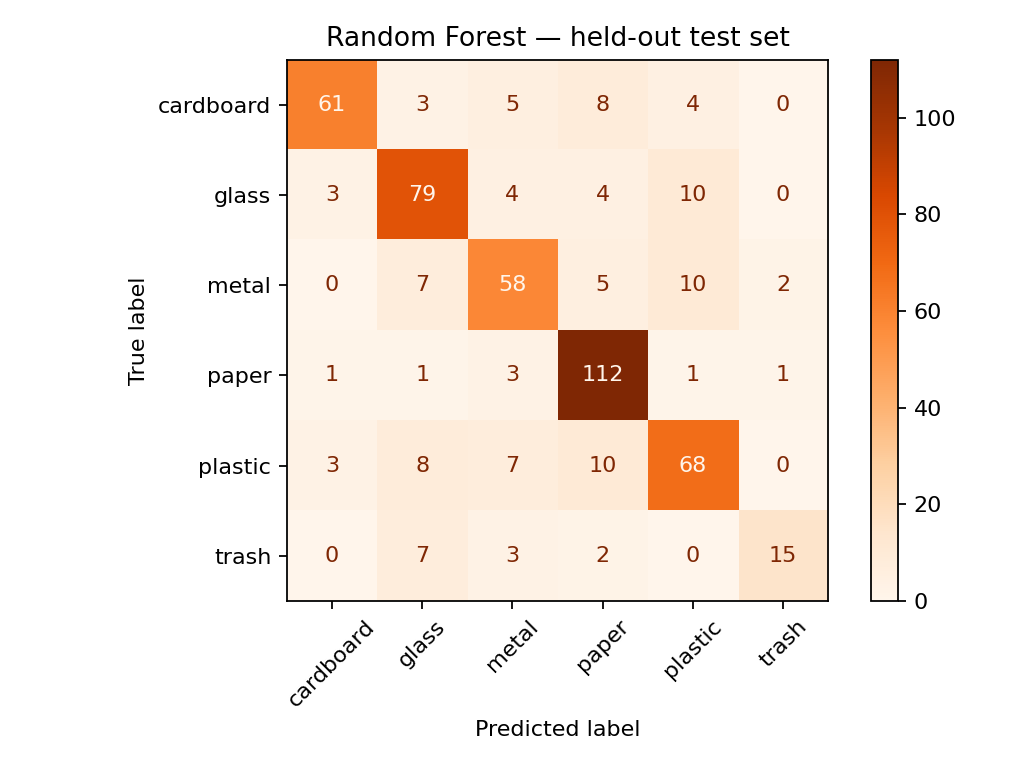

ผลของโมเดลที่เลือกบนชุด Test 


,precision,recall,f1-score,support
cardboard,0.897059,0.753086,0.818792,81.000000
glass,0.752381,0.790000,0.770732,100.000000
metal,0.725000,0.707317,0.716049,82.000000
paper,0.794326,0.941176,0.861538,119.000000
plastic,0.731183,0.708333,0.719577,96.000000
trash,0.833333,0.555556,0.666667,27.000000
accuracy,0.778218,0.778218,0.778218,0.778218
macro avg,0.788880,0.742578,0.758892,505.000000
weighted avg,0.781323,0.778218,0.775671,505.000000


In [ ]:
# Selection uses validation only. Refit on train+validation, then assess unseen test data.
for name, model in models.items():
    model.fit(x[trainval], y[trainval]); predicted=model.predict(x[test])
    result=summary['models'][name]
    result['test']=metrics(y[test],predicted)
    result['classification_report']=classification_report(y[test],predicted, labels=CLASSES, output_dict=True, zero_division=0)
    result['confusion_matrix']=confusion_matrix(y[test],predicted,labels=CLASSES).tolist()
summary['selected_model']=winner
summary['selection_rule']='Highest validation macro F1; test is not used for model selection.'
joblib.dump(dict(model=models[winner], classes=CLASSES, feature_version=1), ARTIFACTS/'model.joblib', compress=3)
(ARTIFACTS/'metrics.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2),encoding='utf-8')

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

colormaps = {
    'SVM': 'Blues',
    'Random Forest': 'Oranges'
}

for name in models:
    cmap = colormaps.get(name, 'Greens')
    ConfusionMatrixDisplay(np.array(summary['models'][name]['confusion_matrix']), display_labels=CLASSES).plot(xticks_rotation=45, cmap=cmap)
    plt.title(name + ' — held-out test set'); plt.tight_layout()
    plt.savefig(ARTIFACTS/(name.replace(' ','_')+'_confusion.png'), dpi=160); plt.close()
print('Selected:', winner, 'Test:', summary['models'][winner]['test'], flush=True)

display(pd.DataFrame({name: info["test"] for name, info in summary["models"].items()}).T)
from IPython.display import display, Image as DisplayImage
for name in models:
    display(DisplayImage(filename=str(ARTIFACTS / (name.replace(" ", "_") + "_confusion.png"))))
print("ผลของโมเดลที่เลือกบนชุด Test ")
display(pd.DataFrame(summary["models"][winner]["classification_report"]).T)

# การแสดงตัวอย่างภาพที่โมเดลทำนายผิด (Misclassified Examples)

จำนวนที่ทำนายผิดทั้งหมดใน Test Set: 112 จาก 505 ภาพ


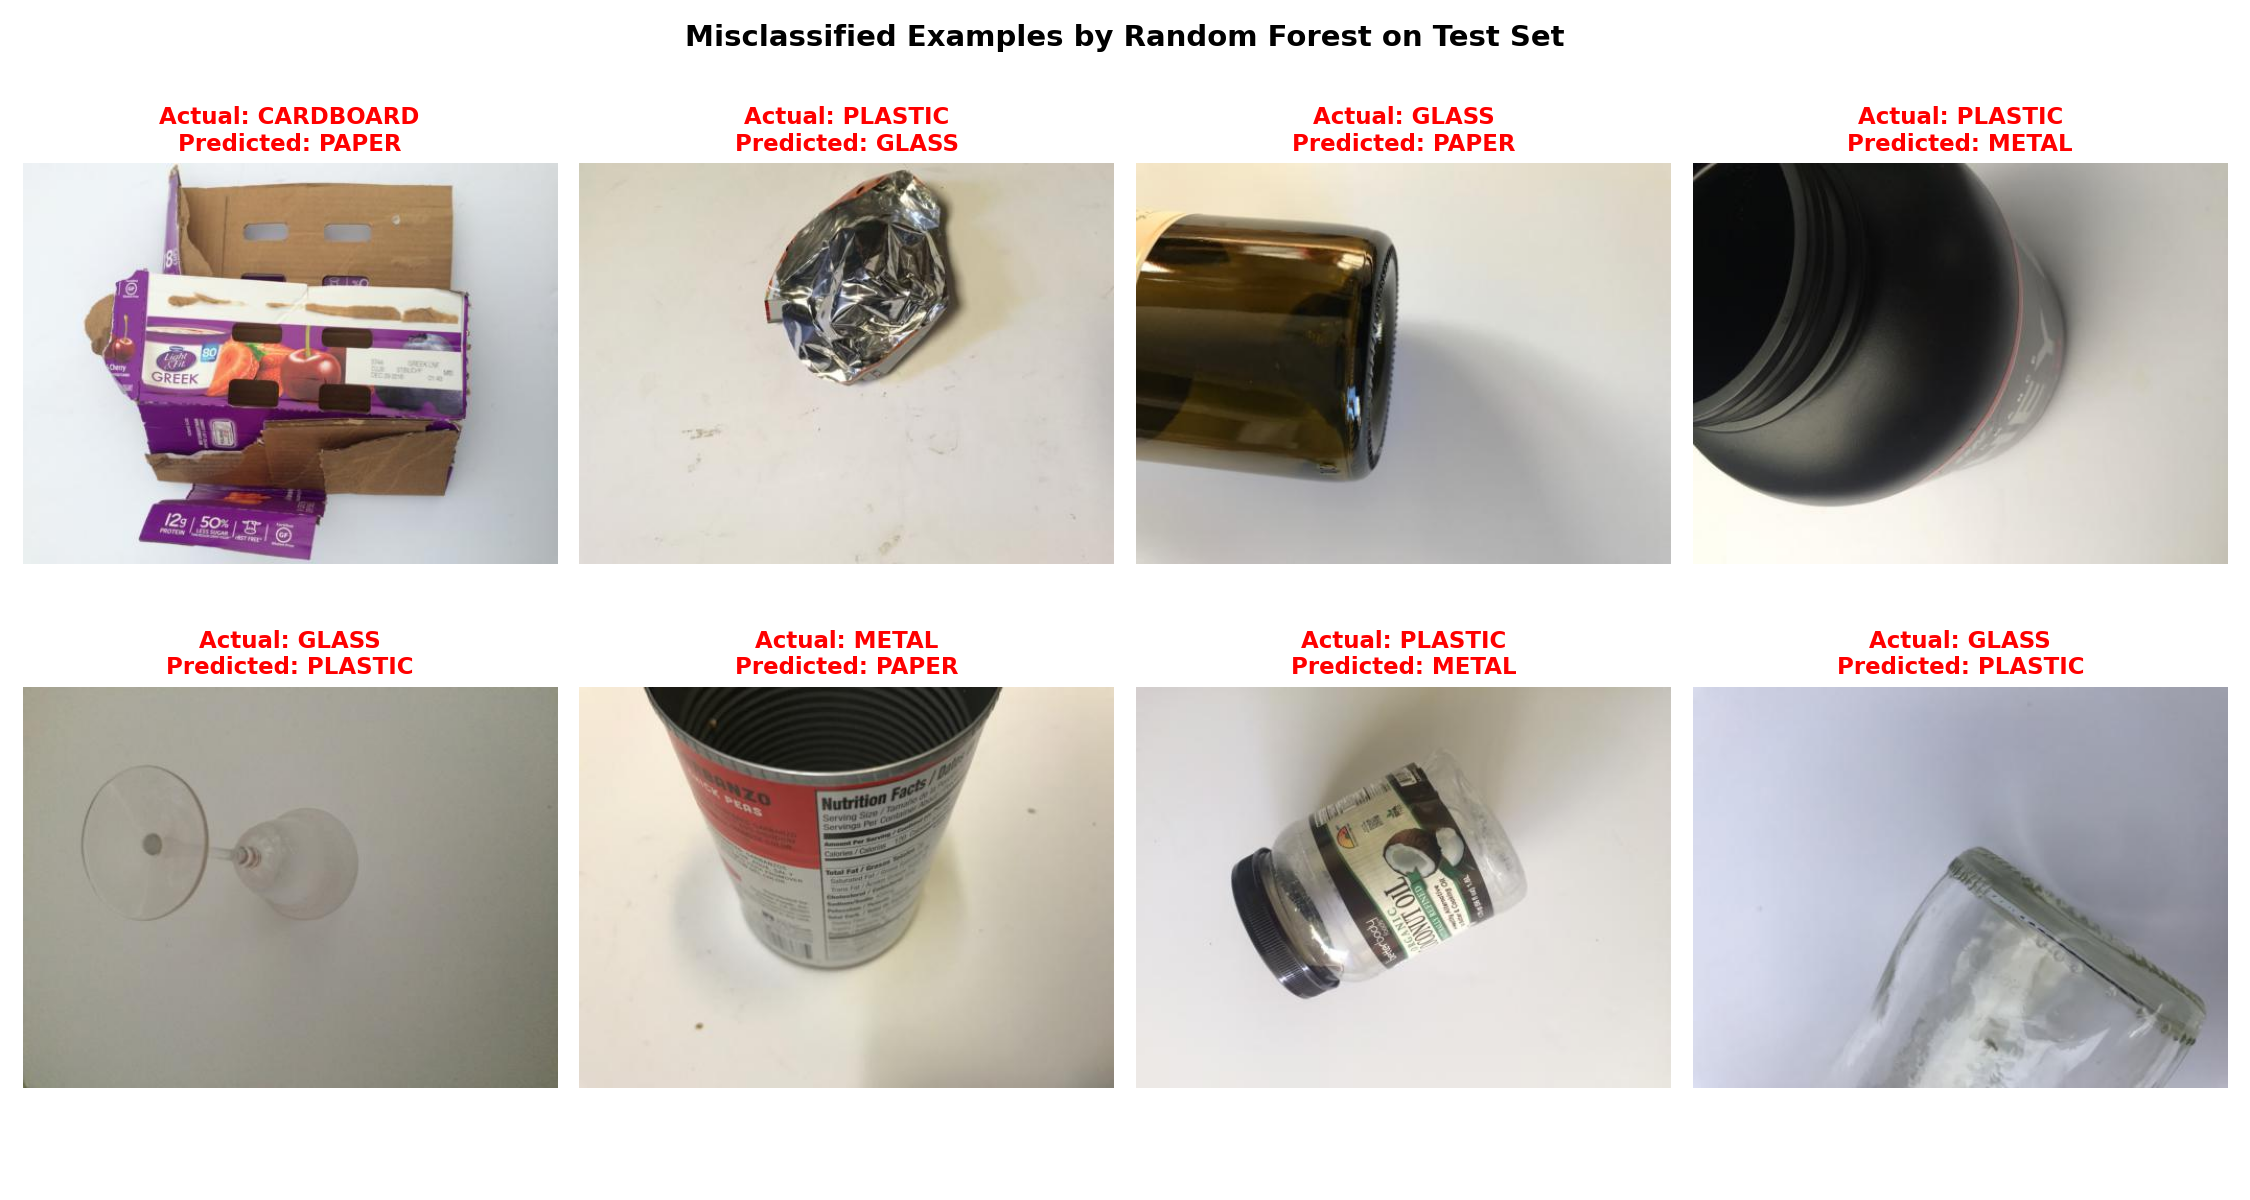

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

winner_model = models[winner]
test_preds = winner_model.predict(x[test])

misclassified_indices = []
for idx, (actual, pred) in enumerate(zip(y[test], test_preds)):
    if actual != pred:
        misclassified_indices.append({
            'test_array_index': idx,
            'dataset_index': test[idx],
            'actual': actual,
            'predicted': pred
        })

print(f"จำนวนที่ทำนายผิดทั้งหมดใน Test Set: {len(misclassified_indices)} จาก {len(test)} ภาพ")

show_limit = min(8, len(misclassified_indices))
if show_limit > 0:
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    axes = axes.ravel()

    for i in range(show_limit):
        item = misclassified_indices[i]
        path, label, _, _ = records[item['dataset_index']]


        try:
            img = Image.open(path)
            axes[i].imshow(img)
        except Exception:
            axes[i].text(0.5, 0.5, "[Error Loading Image]", ha='center', va='center')


        axes[i].set_title(f"Actual: {item['actual'].upper()}\nPredicted: {item['predicted'].upper()}", color='red', fontsize=11, fontweight='bold')
        axes[i].axis('off')

    for j in range(show_limit, 8):
        axes[j].axis('off')

    plt.suptitle(f"Misclassified Examples by {winner} on Test Set", fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig(ARTIFACTS / 'misclassified_examples.png', dpi=150)

    from IPython.display import display, Image as DisplayImage
    plt.close(fig)
    display(DisplayImage(filename=str(ARTIFACTS / 'misclassified_examples.png')))
else:
    print("โมเดลนี้ยอดเยี่ยมมาก! ไม่มีภาพที่ทำนายผิดพลาดเลยใน Test Set")

## 8. เว็บทดลองจำแนกขยะ


In [ ]:
from pathlib import Path
import importlib
import runpy
import sys

ROOT = Path("/content/garbage_sorter")
ROOT.mkdir(parents=True, exist_ok=True)

required = [ROOT / "features.py", ROOT / "artifacts" / "model.joblib"]
missing = [str(path) for path in required if not path.is_file()]
if missing:
    raise FileNotFoundError("ยังขาดไฟล์: " + ", ".join(missing) + " — รันขั้นตอนเตรียมฟังก์ชันและฝึกโมเดลก่อน")

for name in ["demo", "garbage_demo"]:
    previous = globals().get(name)
    if previous is not None and hasattr(previous, "close"):
        previous.close()
import gradio as gr
gr.close_all()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
importlib.invalidate_caches()

sys.modules.pop("features", None)
APP_CODE = 'from pathlib import Path\nimport json\nimport inspect\n\nimport joblib\nimport pandas as pd\nimport gradio as gr\n\nfrom features import THAI, extract_features\n\n\n# =========================================================\n# Paths\n# =========================================================\n\nROOT = Path(__file__).resolve().parent\n\nARTIFACTS = ROOT / "artifacts"\n\n\n# =========================================================\n# Load Model\n# =========================================================\n\nMODEL_PATH = ARTIFACTS / "model.joblib"\n\nif not MODEL_PATH.exists():\n\n    raise FileNotFoundError(\n        "ไม่พบ artifacts/model.joblib "\n        "กรุณารัน train.py ก่อน"\n    )\n\nbundle = joblib.load(\n    MODEL_PATH\n)\n\nselected_model = bundle["model"]\n\n\n# =========================================================\n# หา Model Name\n# =========================================================\n\nmodel_name = type(\n    selected_model\n).__name__\n\nif model_name == "Pipeline":\n\n    model_name = " + ".join(\n        type(step).__name__\n        for _, step\n        in selected_model.steps\n    )\n\n\n# =========================================================\n# คำแนะนำ\n# =========================================================\n\nADVICE = {\n\n    "cardboard":\n        "เก็บกระดาษแข็งให้สะอาดและแห้ง "\n        "พับให้แบนก่อนส่งจุดรับรีไซเคิล",\n\n    "glass":\n        "แยกภาชนะแก้วตามเงื่อนไขจุดรับ "\n        "ระวังแก้วแตกและขอบคม",\n\n    "metal":\n        "แยกกระป๋องหรือโลหะที่สะอาด "\n        "ส่งจุดรับรีไซเคิล",\n\n    "paper":\n        "เก็บให้แห้ง "\n        "แยกกระดาษเปื้อนอาหารก่อนส่งจุดรับรีไซเคิล",\n\n    "plastic":\n        "ตรวจชนิดพลาสติก "\n        "เทของเหลวออก "\n        "แล้วแยกตามเงื่อนไขจุดรับ",\n\n    "trash":\n        "ตรวจวัสดุด้วยตนเอง "\n        "หากรีไซเคิลไม่ได้ให้ทิ้งตามระบบขยะทั่วไปของพื้นที่"\n}\n\n\n# =========================================================\n# ตารางเปรียบเทียบ\n# =========================================================\n\ndef get_comparison_table():\n\n    metrics_file = ARTIFACTS / "metrics.json"\n\n    columns = [\n        "โมเดล",\n        "Accuracy",\n        "Precision (Macro)",\n        "Recall (Macro)",\n        "F1-Score (Macro)"\n    ]\n\n    if not metrics_file.exists():\n\n        return pd.DataFrame(\n            columns=columns\n        )\n\n    try:\n\n        with open(\n            metrics_file,\n            "r",\n            encoding="utf-8"\n        ) as f:\n\n            data = json.load(f)\n\n        comparison_data = []\n\n        for name, results in data.get(\n            "models",\n            {}\n        ).items():\n\n            metrics_test = results.get(\n                "test",\n                results.get(\n                    "validation",\n                    {}\n                )\n            )\n\n            comparison_data.append({\n\n                "โมเดล": name,\n\n                "Accuracy":\n                    f"{metrics_test.get(\'accuracy\', 0):.2%}",\n\n                "Precision (Macro)":\n                    f"{metrics_test.get(\'precision_macro\', 0):.2%}",\n\n                "Recall (Macro)":\n                    f"{metrics_test.get(\'recall_macro\', 0):.2%}",\n\n                "F1-Score (Macro)":\n                    f"{metrics_test.get(\'f1_macro\', 0):.2%}"\n            })\n\n        return pd.DataFrame(\n            comparison_data\n        )\n\n    except Exception:\n\n        return pd.DataFrame(\n            columns=columns\n        )\n\n\n# =========================================================\n# Prediction\n# =========================================================\n\ndef predict_waste(image):\n\n    if image is None:\n\n        raise gr.Error(\n            "กรุณาเลือกหรือถ่ายภาพก่อน"\n        )\n\n    try:\n\n        feature = extract_features(\n            image\n        )[None, :]\n\n        label = str(\n            selected_model.predict(\n                feature\n            )[0]\n        )\n\n        # Probability\n        if hasattr(\n            selected_model,\n            "predict_proba"\n        ):\n\n            probabilities = (\n                selected_model\n                .predict_proba(feature)[0]\n            )\n\n            scores = {\n                THAI[str(c)]:\n                    float(p)\n\n                for c, p in zip(\n                    selected_model.classes_,\n                    probabilities\n                )\n            }\n\n            confidence = scores[\n                THAI[label]\n            ]\n\n        else:\n\n            scores = {}\n\n            confidence = None\n\n        # =================================================\n        # Result Text\n        # =================================================\n\n        text = (\n            f"### ♻️ ประเภทที่คาดว่าเป็น: "\n            f"{THAI[label]}\\n\\n"\n            f"**คะแนนความมั่นใจ:** "\n            f"{format(confidence, \'.1%\') if confidence is not None else \'โมเดลนี้ไม่มีคะแนน probability\'}\\n\\n"\n            f"💡 **คำแนะนำ:** "\n            f"{ADVICE[label]}"\n        )\n\n        if confidence is not None and confidence < 0.60:\n\n            text += (\n                "\\n\\n⚠️ **คะแนนต่ำกว่า 60%** "\n                "กรุณาตรวจวัสดุด้วยตนเอง "\n                "หรือถ่ายภาพใหม่"\n            )\n\n        return text, scores\n\n    except Exception as e:\n\n        raise gr.Error(\n            f"เกิดข้อผิดพลาดในการทำนาย: {e}"\n        )\n\n\n\nimport html\n\ndef comparison_table(part):\n    columns = ["โมเดล", "Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]\n    path = ARTIFACTS / "metrics.json"\n    if not path.exists():\n        return pd.DataFrame(columns=columns)\n    data = json.loads(path.read_text(encoding="utf-8"))\n    rows=[]\n    for name, info in data.get("models", {}).items():\n        values = info.get(part)\n        if not values:\n            continue\n        rows.append([name] + [f"{values[key]:.2%}" if key in values else "—"\n                              for key in ["accuracy", "precision_macro", "recall_macro", "f1_macro"]])\n    return pd.DataFrame(rows, columns=columns)\n\nEMPTY_RESULT = """<div class="empty-result"><div class="empty-icon">♻</div><h3>พร้อมช่วยคุณแยกขยะ</h3><p>เลือกภาพทางด้านซ้าย แล้วกดจำแนกขยะ<br>ผลและคำแนะนำจะปรากฏที่นี่</p></div>"""\nEMPTY_SCORES = \'<div class="score-placeholder">คะแนนทั้ง 6 ประเภทจะแสดงหลังวิเคราะห์ภาพ</div>\'\n\ndef clear_results(image=None):\n    message = "เลือกภาพแล้ว · กดปุ่มจำแนกเพื่อเริ่มวิเคราะห์" if image is not None else "พร้อมใช้งาน · อัปโหลดหรือถ่ายภาพขยะหนึ่งชิ้น"\n    return EMPTY_RESULT, EMPTY_SCORES, message\n\ndef classify_image(image):\n    if image is None:\n        return EMPTY_RESULT, EMPTY_SCORES, "⚠ กรุณาเลือกหรือถ่ายภาพก่อนจำแนก"\n    try:\n        _, scores = predict_waste(image)\n        feature = extract_features(image)[None, :]\n        label = str(selected_model.predict(feature)[0])\n        category = THAI[label]\n        confidence = scores.get(category)\n        low = confidence is not None and confidence < 0.60\n        badge = "ควรตรวจสอบอีกครั้ง" if low else "วิเคราะห์เสร็จแล้ว"\n        score_text = f"{confidence:.1%}" if confidence is not None else "ไม่มีคะแนน probability"\n        panel = f\'<div class="prediction-card"><span class="result-badge {"low" if low else ""}">{badge}</span><p class="eyebrow">ประเภทที่คาดว่าเป็น</p><h2>{html.escape(category)}</h2><p class="english-name">{html.escape(label.title())}</p><div class="confidence-line"><span>คะแนนความน่าจะเป็น</span><strong>{score_text}</strong></div><div class="advice"><strong>แนวทางคัดแยก</strong><p>{html.escape(ADVICE[label])}</p></div>\'\n        if low:\n            panel += \'<div class="low-note">⚠ คะแนนต่ำกว่า 60% กรุณาตรวจวัสดุด้วยตนเอง หรือถ่ายภาพใหม่ให้ชัดขึ้น</div>\'\n        panel += \'</div>\'\n        bars = \'<div class="score-list">\'\n        for name, value in sorted(scores.items(),key=lambda item:item[1],reverse=True):\n            bars += f\'<div class="score-item"><div><span>{html.escape(name)}</span><strong>{value:.1%}</strong></div><div class="bar-track"><div class="bar-fill" style="width:{value*100:.2f}%"></div></div></div>\'\n        bars += \'</div>\'\n        return panel, bars, "✓ วิเคราะห์เสร็จแล้ว · ตรวจวัสดุจริงประกอบผลทำนาย"\n    except Exception as exc:\n        return EMPTY_RESULT, EMPTY_SCORES, "⚠ วิเคราะห์ไม่สำเร็จ: " + str(exc)\n\ncustom_theme=gr.themes.Soft(primary_hue="green",secondary_hue="emerald",neutral_hue="slate").set(\n    body_background_fill="#f0f8f2",body_background_fill_dark="#f0f8f2",\n    body_text_color="#173c2b",body_text_color_dark="#173c2b",\n    block_background_fill="#ffffff",block_background_fill_dark="#ffffff",\n    button_primary_background_fill="#1b5e3c",button_primary_background_fill_dark="#1b5e3c",\n    button_primary_text_color="#ffffff",button_primary_text_color_dark="#ffffff")\ncustom_css="""\n.gradio-container {max-width:1180px!important;margin:auto!important;background:#f0f8f2!important;color:#173c2b!important;font-family:Tahoma,Arial,sans-serif!important}\n.brand-bar {display:flex;align-items:center;gap:12px;padding:18px 4px;border-bottom:1px solid #dce9df;margin-bottom:20px}\n.brand-icon {display:grid;place-items:center;background:#1b5e3c;color:white;width:44px;height:44px;border-radius:14px;font-size:28px}\n.brand-bar strong {display:block;font-size:17px}.brand-bar small {color:#718476}\n.hero {padding:14px 2px 26px}.hero .tag {display:inline-block;padding:6px 12px;border-radius:30px;background:#dceee0;color:#216540;font-size:12px;margin-bottom:12px}\n.hero h1 {font-size:34px;line-height:1.5;letter-spacing:-.5px;color:#174e31;margin:4px 0 10px}.hero p {color:#63786b;max-width:780px;line-height:1.8;margin:0}\n#input-card,#output-card {background:white!important;border:1px solid #e0ebe2!important;border-radius:22px!important;padding:24px!important;box-shadow:0 8px 28px #1b5e3c06}\n#input-image {border-radius:16px!important;background:#f4f9f5!important}\n#predict-button {border-radius:12px!important;min-height:52px!important;font-size:16px!important}\n#reset-button {border-radius:12px!important;min-height:52px!important}\n.empty-result {text-align:center;padding:28px 12px 34px;color:#718476}.empty-result h3 {font-size:21px;color:#28543a;margin:18px 0 10px}.empty-result p {line-height:1.9}\n.empty-icon {background:#eaf5ed;border-radius:50%;width:82px;height:82px;display:grid;place-items:center;margin:auto;font-size:42px;color:#31734a}\n.score-placeholder {padding:18px;text-align:center;background:#f5f9f6;border-radius:12px;color:#839187;font-size:13px}\n.prediction-card .eyebrow {font-size:13px;color:#76877b;margin:22px 0 5px}.prediction-card h2 {font-size:36px;color:#1b5e3c;margin:0;line-height:1.5}.english-name {color:#809087;margin:0 0 20px}\n.result-badge {display:inline-block;background:#e2f4e8;color:#216940;border-radius:20px;padding:6px 12px;font-size:12px}.result-badge.low {background:#fff1d4;color:#8b6215}\n.confidence-line {display:flex;justify-content:space-between;align-items:center;padding:15px 0;border-top:1px solid #e5eee7}.confidence-line strong {font-size:24px;color:#216940}\n.advice {background:#edf7ef;padding:16px;border-radius:14px;margin:10px 0 18px}.advice p {line-height:1.8;margin:8px 0 0;color:#526b59}\n.low-note {background:#fff7e6;border-radius:12px;padding:12px;color:#8b6215;line-height:1.8;font-size:13px;margin-bottom:18px}\n.score-list {padding:6px 0}.score-item {margin:0 0 14px}.score-item>div:first-child {display:flex;justify-content:space-between;font-size:13px;margin-bottom:7px}.bar-track {height:8px;background:#edf3ef;border-radius:10px;overflow:hidden}.bar-fill {height:100%;background:#3b8b5a;border-radius:10px}\n.tips-grid {display:grid;grid-template-columns:1fr 1fr;gap:16px;margin:20px 0}.tip-card {background:white;padding:22px;border:1px solid #e0ebe2;border-radius:18px}.tip-card h3 {font-size:16px;color:#295a3c;margin:0 0 10px}.tip-card p {color:#708176;font-size:13px;line-height:1.9;margin:0}\n.footer-note {text-align:center;color:#8a988e;font-size:12px;padding:16px}\n@media(max-width:700px){.hero h1{font-size:26px}#input-card,#output-card{padding:16px!important}.tips-grid{grid-template-columns:1fr}.brand-bar strong{font-size:14px}}\n"""\nblock_options={}\nif "theme" in inspect.signature(gr.Blocks.__init__).parameters:\n    block_options.update(theme=custom_theme,css=custom_css)\nwith gr.Blocks(title="ระบบจำแนกขยะจากภาพ",**block_options) as demo:\n    gr.HTML(\'<div class="brand-bar"><div class="brand-icon">♻</div><div><strong>ระบบจำแนกขยะจากภาพ</strong><small>Waste Classification · โครงงาน Machine Learning</small></div></div>\')\n    gr.HTML(\'<section class="hero"><span class="tag">แยกให้ถูก เริ่มจากรู้จักวัสดุ</span><h1>ให้ภาพช่วยคุณแยกขยะ</h1><p>อัปโหลดหรือถ่ายภาพขยะทีละชิ้น เพื่อจำแนกวัสดุ 6 ประเภท พร้อมคำแนะนำในการคัดแยก</p></section>\')\n    gr.Markdown("**โมเดลที่ใช้งาน:** " + model_name)\n    status=gr.Markdown("พร้อมใช้งาน · อัปโหลดหรือถ่ายภาพขยะหนึ่งชิ้น")\n    with gr.Row(equal_height=False):\n        with gr.Column(scale=5,min_width=300,elem_id="input-card"):\n            gr.Markdown("### ① เลือกภาพขยะ")\n            gr.Markdown("อัปโหลดจากเครื่อง หรือเลือกไอคอนกล้องเพื่อถ่ายภาพ")\n            input_image=gr.Image(type="pil",sources=["upload","webcam"],label="ภาพขยะ",height=320,elem_id="input-image")\n            with gr.Row():\n                button=gr.Button("♻ จำแนกขยะ",variant="primary",elem_id="predict-button",scale=3)\n                reset=gr.Button("เริ่มใหม่",elem_id="reset-button",scale=1)\n            gr.Markdown("ถ่ายภาพทีละชิ้น ให้เห็นวัสดุชัดเจนบนพื้นหลังเรียบ")\n        with gr.Column(scale=6,min_width=300,elem_id="output-card"):\n            gr.Markdown("### ② ผลการจำแนก")\n            result=gr.HTML(EMPTY_RESULT)\n            gr.Markdown("**คะแนนของแต่ละประเภท**")\n            score_chart=gr.HTML(EMPTY_SCORES)\n            gr.Markdown("คะแนนโมเดลไม่ใช่การรับประกันความถูกต้อง")\n    button.click(classify_image,inputs=input_image,outputs=[result,score_chart,status],api_name="classify_image")\n    input_image.change(clear_results,inputs=input_image,outputs=[result,score_chart,status],queue=False)\n    reset.click(lambda:(None,EMPTY_RESULT,EMPTY_SCORES,"พร้อมใช้งาน · เลือกภาพใหม่ได้เลย"),outputs=[input_image,result,score_chart,status],queue=False)\n    with gr.Accordion("ดูผลประเมินและการเลือกโมเดล",open=False):\n        gr.Markdown("เลือกโมเดลจาก **Validation Macro F1** ส่วน Test ใช้ประเมินหลังเลือกแล้ว คะแนนทั้งสองชุดอาจให้ลำดับโมเดลต่างกัน")\n        with gr.Tabs():\n            with gr.Tab("Validation · ใช้เลือกโมเดล"):\n                gr.Dataframe(value=comparison_table("validation"),interactive=False,wrap=True)\n            with gr.Tab("Test · ผลทดสอบสุดท้าย"):\n                gr.Dataframe(value=comparison_table("test"),interactive=False,wrap=True)\n    gr.HTML(\'<div class="tips-grid"><div class="tip-card"><h3>◉ ถ่ายภาพให้เห็นวัสดุชัด</h3><p>วางขยะหนึ่งชิ้นกลางภาพ ใช้แสงสม่ำเสมอและพื้นหลังเรียบ หลีกเลี่ยงภาพเบลอหรือวัตถุซ้อนกัน</p></div><div class="tip-card"><h3>ⓘ ขอบเขตของระบบ</h3><p>ระบบเลือกจาก 6 ประเภทเสมอ ภาพหลายชิ้นหรือวัสดุผสมอาจทำนายผิด ไม่ใช้ตรวจขยะอันตราย และต้องตรวจเงื่อนไขจุดรับรีไซเคิลจริง</p></div></div><div class="footer-note">กระดาษแข็ง · แก้ว · โลหะ · กระดาษ · พลาสติก · ขยะทั่วไป</div>\')\n\ndef launch_app(share=False,inline=None):\n    options=dict(share=share,inline=inline,prevent_thread_lock=True)\n    if "theme" in inspect.signature(demo.launch).parameters:\n        options.update(theme=custom_theme,css=custom_css)\n    return demo.launch(**options)\n\nif __name__ == "__main__":\n    launch_app()\n'
APP_PATH = ROOT / "app_gradio.py"
APP_PATH.write_text(APP_CODE, encoding="utf-8")

app_namespace = runpy.run_path(str(APP_PATH), run_name="garbage_web")
garbage_demo = app_namespace["demo"]
demo = garbage_demo
print("Gradio version:", gr.__version__)
print("โมเดลที่ใช้:", app_namespace["model_name"])
app_namespace["launch_app"](share=True, inline=True)




Gradio version: 6.27.0
โมเดลที่ใช้: RandomForestClassifier
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://83afdc13c910b1d21e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 9. ดาวน์โหลดโค้ด โมเดล และผลทดลอง
รันเซลล์นี้เพื่อเก็บผลงานก่อนปิด Colab ZIP รวมโมเดล metrics ภาพ confusion matrix และโค้ด โดยไม่รวมชุดข้อมูลที่ดาวน์โหลดจาก Kaggle


In [ ]:
import shutil
import json
import importlib.metadata
from pathlib import Path
from google.colab import files

train_code = '''"""Clean images, compare two sklearn classifiers, select by validation macro F1."""
import argparse, csv, hashlib, json, time
from collections import Counter
from pathlib import Path
import joblib
import numpy as np
from PIL import Image, UnidentifiedImageError
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from features import CLASSES, extract_features, prepare_image

ROOT = Path(__file__).resolve().parent

def metrics(y, prediction):
    p, r, f, _ = precision_recall_fscore_support(y, prediction, average="macro", zero_division=0)
    return dict(accuracy=float(accuracy_score(y, prediction)), precision_macro=float(p), recall_macro=float(r), f1_macro=float(f))

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--data", type=Path, default=ROOT/"data")
    parser.add_argument("--output", type=Path, default=ROOT/"artifacts")
    args = parser.parse_args()
    args.output.mkdir(parents=True, exist_ok=True)
    records, seen, skipped, conflicts = [], {}, [], set()
    for path in sorted(args.data.rglob("*")):
        if not path.is_file() or path.suffix.lower() not in {".jpg",".jpeg",".png",".bmp",".webp"}:
            continue
        label = path.parent.name.lower()
        if label not in CLASSES:
            continue
        try:
            with Image.open(path) as image:
                rgb = image.convert("RGB")
                digest = hashlib.sha256(str(rgb.size).encode() + rgb.tobytes()).hexdigest()
                feature = extract_features(image)
            if digest in seen:
                if seen[digest] != label:
                    conflicts.add(digest)
                skipped.append(dict(path=str(path), reason="conflicting_duplicate" if seen[digest] != label else "duplicate"))
                continue
            seen[digest] = label
            records.append((path, label, feature, digest))
        except (UnidentifiedImageError, OSError, Image.DecompressionBombError) as exc:
            skipped.append(dict(path=str(path), reason=str(exc)))
    for path,label,feature,digest in records:
        if digest in conflicts:
            skipped.append(dict(path=str(path), reason="conflicting_duplicate"))
    records = [r for r in records if r[3] not in conflicts]
    counts = Counter(r[1] for r in records)
    if any(counts[c] < 10 for c in CLASSES):
        raise ValueError(f"Need at least 10 valid unique images per class; found {dict(counts)}. Extract Kaggle dataset under data/.")
    x = np.stack([r[2] for r in records]); y = np.array([r[1] for r in records])
    indices = np.arange(len(y))
    trainval, test = train_test_split(indices, test_size=.2, random_state=42, stratify=y)
    train, valid = train_test_split(trainval, test_size=.25, random_state=42, stratify=y[trainval])
    split = {int(i):name for name, group in [("train",train),("validation",valid),("test",test)] for i in group}
    with (args.output/"split_manifest.csv").open("w", newline="", encoding="utf-8") as f:
        writer=csv.writer(f); writer.writerow(["path","class","split","pixel_sha256"])
        for i, (path,label,_,digest) in enumerate(records):
            writer.writerow([str(path.relative_to(args.data)),label,split[i],digest])
    models = {
        "SVM": make_pipeline(StandardScaler(), SVC(C=10, kernel="rbf", class_weight="balanced", probability=True, random_state=42)),
        "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", min_samples_leaf=2, random_state=42, n_jobs=-1)
    }
    summary = dict(class_counts=dict(counts), skipped=skipped, feature_count=int(x.shape[1]),
                   split_counts={k:len(v) for k,v in [("train",train),("validation",valid),("test",test)]}, seed=42, models={})
    for name, model in models.items():
        start=time.time(); model.fit(x[train], y[train])
        summary["models"][name] = dict(validation=metrics(y[valid], model.predict(x[valid])), fit_seconds=time.time()-start)
    winner = max(models, key=lambda name: summary["models"][name]["validation encamp"]["f1_macro"] if "validation encamp" in summary["models"][name] else summary["models"][name]["validation"]["f1_macro"])
    for name, model in models.items():
        model.fit(x[trainval], y[trainval]); predicted=model.predict(x[test])
        result=summary["models"][name]
        result["test"]=metrics(y[test],predicted)
        result["classification_report"]=classification_report(y[test],predicted, labels=CLASSES, output_dict=True, zero_division=0)
        result["confusion_matrix"]=confusion_matrix(y[test],predicted,labels=CLASSES).tolist()
    summary["selected_model"]=winner
    summary["selection_rule"]="Highest validation macro F1; test is not used for model selection."
    joblib.dump(dict(model=models[winner], classes=CLASSES, feature_version=1), args.output/"model.joblib", compress=3)
    (args.output/"metrics.json").write_text(json.dumps(summary,ensure_ascii=False,indent=2),encoding="utf-8")

if __name__ == "__main__":
    main()
'''
(ROOT / "train.py").write_text(train_code, encoding="utf-8")

# 2. เขียนไฟล์ app_gradio.py สำหรับรันหน้ากากเว็บแอปพร้อมธีมสีตามดีไซน์
app_code = '''from pathlib import Path
import json
import joblib
import pandas as pd
from features import THAI, extract_features
import gradio as gr

ARTIFACTS = Path(__file__).resolve().parent / "artifacts"
bundle = joblib.load(ARTIFACTS / "model.joblib")
selected_model = bundle["model"]
model_name = type(selected_model).__name__
if model_name == "Pipeline":
    model_name = " ".join([type(step).__name__ for name, step in selected_model.steps])

ADVICE = {
    "cardboard": "เก็บกระดาษแข็งให้สะอาดและแห้ง พับให้แบนก่อนส่งจุดรับรีไซเคิล",
    "glass": "แยกภาชนะแก้วตามเงื่อนไขจุดรับ ระวังแก้วแตกและขอบคม",
    "metal": "แยกกระป๋องหรือโลหะที่สะอาด ส่งจุดรับรีไซเคิล",
    "paper": "เก็บให้แห้ง แยกกระดาษเปื้อนอาหารก่อนส่งจุดรับรีไซเคิล",
    "plastic": "ตรวจชนิดพลาสติก เทของเหลวออก แล้วแยกตามเงื่อนไขจุดรับ",
    "trash": "ตรวจวัสดุด้วยตนเอง หากรีไซเคิลไม่ได้ให้ทิ้งตามระบบขยะทั่วไปของพื้นที่"
}

def get_comparison_table():
    metrics_file = ARTIFACTS / "metrics.json"
    if not metrics_file.exists():
        return pd.DataFrame(columns=["โมเดล", "Accuracy", "Precision (Macro)", "Recall (Macro)", "F1-Score (Macro)"])
    try:
        with open(metrics_file, "r", encoding="utf-8") as f:
            data = json.load(f)
        comparison_data = []
        for name, results in data.get("models", {}).items():
            metrics_val = results.get("test", results.get("validation", {}))
            comparison_data.append({
                "โมเดล": name,
                "Accuracy": f"{metrics_val.get('accuracy', 0):.2%}",
                "Precision (Macro)": f"{metrics_val.get('precision_macro', 0):.2%}",
                "Recall (Macro)": f"{metrics_val.get('recall_macro', 0):.2%}",
                "F1-Score (Macro)": f"{metrics_val.get('f1_macro', 0):.2%}"
            })
        return pd.DataFrame(comparison_data)
    except Exception:
        return pd.DataFrame(columns=["โมเดล", "Accuracy", "Precision (Macro)", "Recall (Macro)", "F1-Score (Macro)"])

def predict_waste(image):
    if image is None:
        raise gr.Error("กรุณาเลือกหรือถ่ายภาพก่อน")
    feature = extract_features(image)[None, :]
    label = str(selected_model.predict(feature)[0])
    probabilities = selected_model.predict_proba(feature)[0]
    scores = {THAI[str(c)]: float(p) for c, p in zip(selected_model.classes_, probabilities)}
    confidence = scores[THAI[label]]
    text = f"### ประเภทที่คาดว่าเป็น: {THAI[label]}\nคะแนนประเภทนี้: {confidence:.1%}\n\n{ADVICE[label]}"
    if confidence < 0.6:
        text += "\n\n⚠️ คะแนนต่ำกว่า 60% กรุณาตรวจวัสดุด้วยตนเองหรือถ่ายใหม่"
    return text, scores

custom_theme = gr.themes.Soft(
    primary_hue=gr.themes.colors.Color(
        name="sky_blue",
        c50="#f0f8ff", c100="#e0f2fe", c200="#bae6fd", c300="#8ACFF8", c400="#38bdf8",
        c500="#0ea5e9", c600="#0284c7", c700="#0369a1", c800="#075985", c900="#0c4a6e", c950="#082f49"
    ),
    secondary_hue=gr.themes.colors.slate,
    neutral_hue=gr.themes.colors.slate
).set(
    body_background_fill="#ffffff",
    body_background_fill_dark="#0f172a",
    block_background_fill="#fcfdfed6",
    button_primary_background_fill="#8ACFF8",
    button_primary_background_fill_hover="#38bdf8",
    button_primary_text_color="#0c4a6e",
    button_primary_text_color_hover="#ffffff",
    body_text_color="#1e293b"
)

with gr.Blocks(title="ระบบจำแนกขยะ", theme=custom_theme) as demo:
    gr.Markdown(f"# ♻️ ระบบจำแนกขยะจากภาพ\nถ่ายขยะทีละชิ้นบนพื้นหลังเรียบ จำแนกได้ 6 ประเภท (ใช้โมเดล: **{model_name}**)")
    with gr.Row():
        with gr.Column():
            input_image = gr.Image(type="pil", sources=["upload", "webcam"], label="ภาพขยะ")
            button = gr.Button("จำแนกขยะ", variant="primary")
        with gr.Column():
            result = gr.Markdown("เลือกภาพแล้วกดจำแนกขยะ")
            score_chart = gr.Label(num_top_classes=6, label="คะแนนโมเดลแต่ละประเภท")
    button.click(predict_waste, inputs=input_image, outputs=[result, score_chart])
    gr.Markdown("เป็นระบบต้นแบบ ภาพหลายชิ้นหรือวัสดุผสมอาจทำนายผิด ไม่ใช้ตรวจขยะอันตราย และต้องตรวจเงื่อนไขจุดรับรีไซเคิลจริง")

    gr.Markdown("## 📊 ตารางเปรียบเทียบประสิทธิภาพของโมเดล (อัปเดตอัตโนมัติ)")
    gr.DataFrame(value=get_comparison_table, interactive=False)

if __name__ == "__main__":
    demo.launch()
'''
(ROOT / "app_gradio.py").write_text(app_code, encoding="utf-8")

versions = {
    "numpy": importlib.metadata.version("numpy"),
    "pillow": importlib.metadata.version("pillow"),
    "scikit-learn": importlib.metadata.version("scikit-learn"),
    "scikit-image": importlib.metadata.version("scikit-image"),
    "matplotlib": importlib.metadata.version("matplotlib"),
    "pandas": importlib.metadata.version("pandas"),
    "joblib": importlib.metadata.version("joblib"),
    "gradio": importlib.metadata.version("gradio"),
    "kagglehub": importlib.metadata.version("kagglehub")
}
(ARTIFACTS / "environment.json").write_text(json.dumps(versions, indent=2), encoding="utf-8")

download_path = "/content/garbage_sorter_results.zip"
if Path(download_path).exists():
    Path(download_path).unlink()
shutil.make_archive("/content/garbage_sorter_results", "zip", str(ROOT))

files.download(download_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## อภิปรายและอ้างอิง
จุดเด่น: ทำงานด้วย CPU, อธิบายการเตรียมข้อมูลและ feature ได้, ไม่มี API ทำนายภายนอก จุดอ่อน: รูปร่างและสีคล้ายกันอาจสับสน, ภาพพื้นหลังรกและภาพหลายชิ้นยังไม่ได้ประเมิน, ตัดเฉพาะภาพที่พิกเซลเหมือนกัน จึงอาจยังมีภาพวัตถุเดียวกันคนละมุมข้าม split

แนวทางพัฒนา: เก็บภาพสภาพจริง เพิ่มข้อมูลกลุ่มที่มีน้อย จัดกลุ่มตามวัตถุก่อนแบ่งข้อมูล ใช้ cross-validation บน train+validation เพื่อปรับ hyperparameters และประเมิน calibration โดยไม่ใช้ test ปรับเกณฑ์

- [Kaggle Garbage Classification](https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification)
- [Scikit-learn SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)
- [Scikit-learn Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
- [Scikit-image HOG](https://scikit-image.org/docs/stable/api/skimage.feature.html#skimage.feature.hog)
- [KaggleHub](https://github.com/Kaggle/kagglehub)
- [Gradio](https://www.gradio.app/guides/sharing-your-app)
